# UK equity momentum

The annually selected momentum strategy returned -6.65% over 2024–2025 after modelled transaction costs, compared with -0.43% for the equal-weight benchmark. Its volatility was greater, and the mean daily net excess was not statistically significant. Hence no edge has been established against this benchmark, but this does not prove that no advantage exists.

This notebook serves as a brief overview of the [original notebook](archive/equity_momentum_research_2026-09-22.ipynb), retaining the key details without all individual checks.

### Imports and setup

Use the saved daily price history and the existing research rules. The loader checks the prepared snapshot against its recorded inputs. No new downloads are needed; missing or changed inputs must be reviewed before rebuilding.

In [ ]:
from pathlib import Path
import json
import sys
import pandas as pd
from IPython.display import display
%matplotlib inline

HERE = Path.cwd().resolve()
PROJECT_DIR = next(
    path for parent in (HERE, *HERE.parents)
    for path in (parent, parent / "uk_portfolio/equity_momentum", parent / "trading_portfolio/uk_portfolio/equity_momentum")
    if (path / "data/raw_momentum_validation_protocol_v1.json").is_file()
)
sys.path.insert(0, str(PROJECT_DIR / "src"))
import momentum_preparation
import momentum_research
import momentum_plotting

PROTOCOL = json.loads((PROJECT_DIR / "data/raw_momentum_validation_protocol_v1.json").read_text())
PERIODS = json.loads((PROJECT_DIR / "data/research_periods_v1.json").read_text())
CAPITAL = PROTOCOL["initial_capital_gbp"]
prepared = momentum_preparation.load_prepared_momentum_data(PROJECT_DIR)
schedule = prepared["schedule"]

METRICS = ["final_equity_gbp", "total_return_pct", "net_cagr_pct", "volatility_pct",
           "sharpe_zero_rf", "max_drawdown_pct", "annual_two_way_turnover", "total_cost_gbp"]
CHOICES = ["train_start", "train_end", "test_start", "configuration_id",
           "formation_sessions", "skip_sessions", "top_frac", "training_sharpe"]
TEST_COLUMNS = ["mean_daily_net_excess_bps", "lower_ci_bps", "upper_ci_bps",
                "p_one_sided", "reject_holm"]

/Users/oscarlewis/Desktop/python/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## Data and universe

Begin with 669 share candidates from a saved Trading 212 GBP/GBX catalogue. Such universe was constructed around ISA usage, avoiding FX conversion and SDRT in order to limit transaction costs. ETFs are excluded from this individual-share project, and are set to be discussed in a future momentum project. Price histories are available for 593 candidates, the rest are unavailable.

For eligibility, require 60 complete sessions of liquidity observations, at least £100,000 median daily traded value, positive reported volume on at least 95% of those sessions, and a usable close with positive volume on the signal day. Each momentum window also needs complete closing history between its endpoints. All configurations rank the same eligible stocks on each date.

Quotes are converted to GBP before trading. Documented suspensions retain holdings and use stale prices for valuation only. They do not provide executable fills. The candidate list is current, so historical eligibility checks do not remove survivorship bias of the universe chosen.

In [ ]:
coverage = prepared["coverage"]
display(coverage.groupby("source").agg(candidates=("yf_symbol", "size")))

period_summary = pd.DataFrame({
    name: {"first_session": dates[0], "last_session": dates[-1], "sessions": len(dates)}
    for name, bounds in PERIODS.items()
    for dates in [momentum_research.sessions_in_period(schedule, bounds)]}).T
display(period_summary)

,candidates
source,
additional_yahoo,20
inherited_reconciled,573
unavailable,76


,first_session,last_session,sessions
warmup,2015-01-02 00:00:00,2015-12-31 00:00:00,253
development,2016-01-04 00:00:00,2021-12-31 00:00:00,1518
validation,2022-01-04 00:00:00,2023-12-29 00:00:00,501
holdout,2024-01-02 00:00:00,2025-12-31 00:00:00,507


## Strategy and execution

The question we seek to answer is, can ranking shares by their past returns improve performance compared with holding the same eligible universe with equal weights? The economic hypothesis is that gradual changes in investor demand can sustain relative price trends, so recent winners may continue to outperform their counterparts. This is the economic motivation behind testing, and is not a reason why this strategy must work.



After the final trading session of each month, calculate each eligible share's momentum:

$$M_{i,t} = \frac{P^{adj}_{i,t-S}}{P^{adj}_{i,t-L}} - 1,$$

where $L$ is the formation period and $S$ is the number of recent sessions skipped. The original baseline uses $L=252$, $S=21$ and the top 20% ranked by this metric. Rank momentum, round the selected stock count upwards, then assign equal target weights. Negative-momentum winners can still be selected. There is no absolute-momentum cash filter.

Execute at the next session's opening reference price, allowing weights to drift until the next rebalance. Both portfolios start with £10,000. Model 10bp per side on the net amount bought or sold, including entry and parameter-switching trades. Fractional units are allowed, with no leverage, shorting, cash interest or forced final liquidation.

The benchmark rebalances monthly across all common eligible shares. It is not buy-and-hold or a market index. Signals are built using adjusted close prices. Opening prices and 10bp costs are modelling assumptions.

In [ ]:
#compute the 18 fixed candidate histories once
sweep, eligibility_at_signals = momentum_research.build_candidate_history(
    prepared, PROTOCOL, PERIODS, progress=False)
development = momentum_research.development_summary(sweep, PERIODS["development"], CAPITAL)

baseline_id = 16  #252 trading days, skip 21, top 20% in the saved grid.
baseline_comparison = pd.concat([development["summary"].loc[[baseline_id], METRICS].rename(index={baseline_id: "Baseline"}),
    development["benchmark_summary"][METRICS]])
display(baseline_comparison.round(2))

,final_equity_gbp,total_return_pct,net_cagr_pct,volatility_pct,sharpe_zero_rf,max_drawdown_pct,annual_two_way_turnover,total_cost_gbp
Baseline,22799.62,128.00,14.66,26.11,0.66,-56.79,8.01,685.05
Benchmark,22717.49,127.17,14.59,18.10,0.84,-53.26,3.55,315.37


See that the baseline and benchmark finish at almost the same value over 2016–2021. Momentum has greater volatility, a worse maximum drawdown and more trading costs. Now perform a parameter sweep on our development period to find which parameters are perform the best

## Parameter sweep: 2016–2021

Test 126, 189 and 252 formation sessions, skipping either zero or 21 sessions, with top fractions of 10%, 20% and 30%. This gives 18 parameter configurations, with rebalancing remaining monthly. All parameter configurations and the benchmark use the same eligible cross-section, so a shorter formation period does not gain access to additional stocks.

In [5]:
development_signal_dates = eligibility_at_signals["execution_date"].lt(PERIODS["development"]["end_exclusive"])
display(eligibility_at_signals.loc[development_signal_dates, "eligible_stocks"].describe().to_frame())
display(development["summary"][[
    "formation_sessions", "skip_sessions", "top_frac", "net_cagr_pct", "cagr_gap_pp",
    "volatility_pct", "sharpe_zero_rf", "max_drawdown_pct"
]].sort_values("net_cagr_pct", ascending=False).round(2))
display(development["annual_gap_pp"].rename_axis(index="configuration_id", columns="year").round(2))

,eligible_stocks
count,72.000000
mean,95.541667
std,37.739633
min,48.000000
25%,70.000000
50%,88.500000
75%,111.000000
max,194.000000


,formation_sessions,skip_sessions,top_frac,net_cagr_pct,cagr_gap_pp,volatility_pct,sharpe_zero_rf,max_drawdown_pct
configuration_id,,,,,,,,
12,252,0,0.1,25.18,10.59,36.42,0.80,-56.53
13,252,0,0.2,21.59,7.00,25.84,0.89,-44.05
6,189,0,0.1,16.46,1.87,35.18,0.61,-51.03
17,252,21,0.3,15.14,0.55,22.49,0.74,-48.96
15,252,21,0.1,14.92,0.33,34.39,0.58,-71.00
16,252,21,0.2,14.66,0.07,26.11,0.66,-56.79
2,126,0,0.3,14.31,-0.28,22.15,0.72,-55.59
14,252,0,0.3,14.12,-0.47,22.68,0.70,-53.96
7,189,0,0.2,13.16,-1.43,25.81,0.61,-51.92


year,2016,2017,2018,2019,2020,2021
configuration_id,,,,,,
0,-21.56,2.15,-33.56,-17.67,112.99,-57.33
1,-12.67,9.10,-19.40,-11.58,113.76,-40.58
2,-13.25,15.69,-6.81,-1.79,60.26,-27.84
3,-4.10,-22.60,-18.41,-28.33,137.83,-51.72
4,-5.97,-18.64,-17.57,-16.36,48.45,-41.26
5,-17.87,-3.55,-11.48,-4.96,38.75,-10.53
6,10.88,28.62,-19.13,14.35,120.31,-56.59
7,7.51,12.13,-13.22,8.16,58.11,-43.55
8,2.73,4.22,-7.32,-1.41,39.53,-30.48


Configurations 12 and 13 have the highest cumulative returns, but these are hindsight development winners. Only six configurations have a higher CAGR than the benchmark, and only configuration 13 has a higher Sharpe ratio. Every configuration outperforms in 2020, but every configuration underperforms in 2018 and 2021. There is a plot of the corresponding equity curves below.

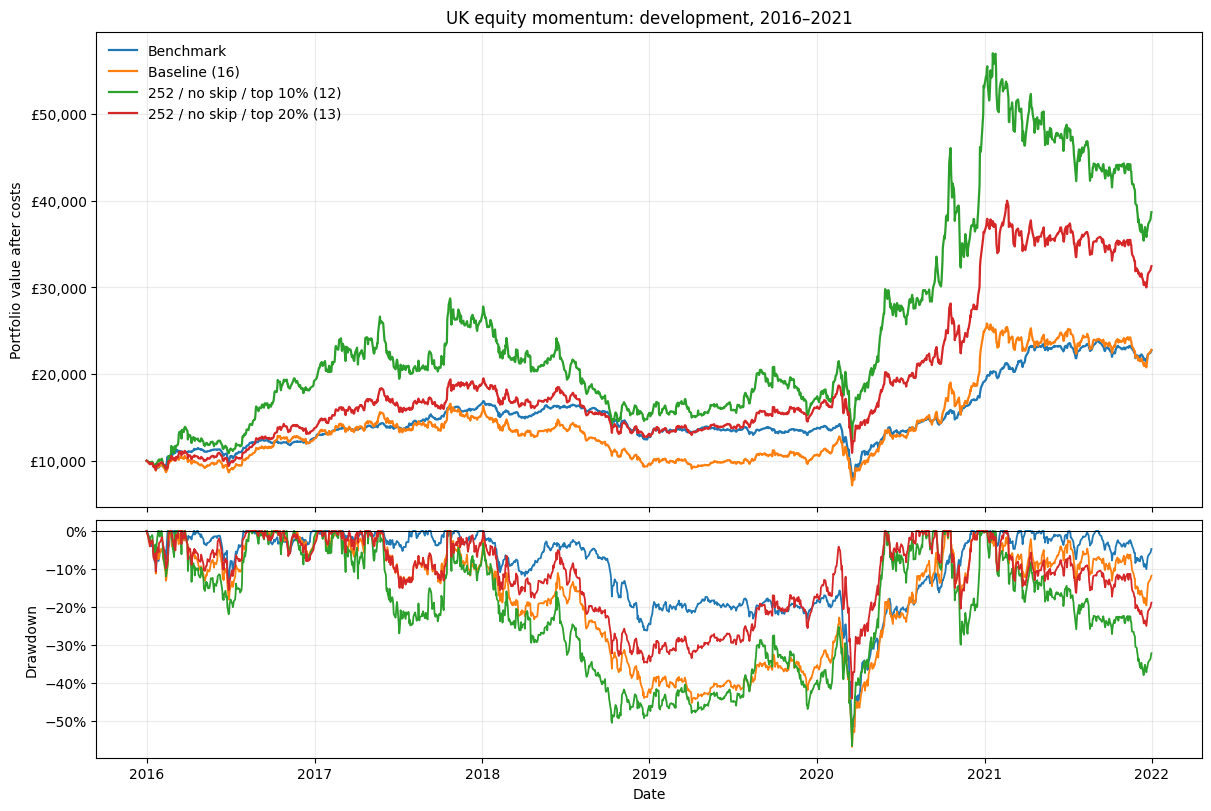

In [ ]:
development_equity = pd.DataFrame({
    "Benchmark": development["benchmark_daily"]["equity_gbp"],
    "Baseline (16)": development["daily"][baseline_id]["equity_gbp"],
    "252 / no skip / top 10% (12)": development["daily"][12]["equity_gbp"],
    "252 / no skip / top 20% (13)": development["daily"][13]["equity_gbp"],
})
fig, axes = momentum_plotting.plot_equity_and_drawdown(
    development_equity, initial_capital_gbp=CAPITAL,
    start_date=schedule.index[schedule.index.get_loc(development_equity.index[0]) - 1],
    title="UK equity momentum: development, 2016 - 2021")

### Significance testing

Test mean daily net excess using a paired circular block bootstrap (10,000 resamples, 63-session blocks and pointwise 95% basic confidence intervals). Use 21 and 126 block sizes as sensitivities. Apply Holm correction across the 18 configurations. The null hypothesis is that mean daily net excess is zero or negative. Tests include transaction costs for both portfolios. Confidence intervals are not simultaneous intervals, and resampling does not repeat parameter selection or correct for the entire research history.

In [ ]:
sweep_inference = momentum_research.test_net_excess(
    development["net_returns"], development["benchmark_daily"]["net_return"], PROTOCOL["inference"])
display(sweep_inference.xs(63, level="block_length").sort_values("p_one_sided").round(4))

sensitivity_counts = sweep_inference.assign(uncorrected=lambda table: table["mean_daily_net_excess_bps"].gt(0)
    & table["p_one_sided"].le(PROTOCOL["inference"]["alpha"])).groupby(level="block_length").agg(
    configurations=("p_one_sided", "size"), uncorrected_passes=("uncorrected", "sum"), holm_passes=("reject_holm", "sum"))
display(sensitivity_counts)

,mean_daily_net_excess_bps,lower_ci_bps,upper_ci_bps,p_one_sided,p_holm,reject_holm
configuration_id,,,,,,
12,5.4806,-3.9813,14.6317,0.1221,1.0,False
13,3.0291,-2.2907,8.2006,0.1276,1.0,False
6,2.4450,-8.0446,12.7894,0.3188,1.0,False
15,1.8066,-7.5116,11.0481,0.3507,1.0,False
16,0.7278,-4.6090,5.9167,0.3911,1.0,False
17,0.5477,-3.6945,4.8666,0.4037,1.0,False
14,0.2103,-3.8678,4.3151,0.4627,1.0,False
2,0.2277,-4.4082,5.0160,0.4709,1.0,False
7,0.1762,-5.9510,6.5690,0.4867,1.0,False


,configurations,uncorrected_passes,holm_passes
block_length,,,
21,18,0,0
63,18,0,0
126,18,0,0


No configuration passes the positive-mean excess test, even before adjustment, at any tested block length. The primary one-sided p-values for configurations 12 and 13 are 0.1221 and 0.1276. All Holm-adjusted p-values equal 1.

## Annual walk-forward

Instead of choosing one configuration from its full development result, select annually using only the previous three calendar years. Choose the highest net training Sharpe ratio, with ties favouring the lowest configuration ID. Keep monthly stock rebalancing. A negative training Sharpe does not trigger a switch to cash.

Run the chosen targets through a continuous ledger, charging the actual trades when configurations change. The 2019–2021 comparison is a development diagnostic, since those years have already been inspected in the sweep.

In [8]:
development_walk_forward = momentum_research.run_walk_forward_period(
    sweep, prepared["market"], schedule, PROTOCOL,
    {"start": "2019-01-01", "end_exclusive": "2022-01-01"})
display(development_walk_forward["choices"][CHOICES].round(3))
display(development_walk_forward["summary"][METRICS].round(2))
display(development_walk_forward["annual"].round(2))

,train_start,train_end,test_start,configuration_id,formation_sessions,skip_sessions,top_frac,training_sharpe
fold,,,,,,,,
0,2016-01-04,2018-12-31,2019-01-02,12,252,0,0.1,0.597
1,2017-01-03,2019-12-31,2020-01-02,11,189,21,0.3,0.371
2,2018-01-02,2020-12-31,2021-01-04,13,252,0,0.2,0.916


,final_equity_gbp,total_return_pct,net_cagr_pct,volatility_pct,sharpe_zero_rf,max_drawdown_pct,annual_two_way_turnover,total_cost_gbp
Walk-forward,16391.45,63.91,17.80,30.70,0.69,-50.74,8.43,336.95
Benchmark,17806.17,78.06,21.08,20.52,1.04,-44.58,3.43,129.08


,Walk-forward,Benchmark,gap_pp
year,,,
2019,11.19,7.29,3.89
2020,65.57,39.65,25.92
2021,-10.96,18.84,-29.80


The development walk-forward ends at £16,391.45 over 2019–2021, compared with £17,806.17 for the benchmark. Outperformance in 2019 and 2020 is removed by an underperformance in 2021.

## Validation: 2022–2023

Fix the configuration above. Then test on the 2022 choice using 2019–2021 for training. Similarly, the 2023 parameter choice uses 2020–2022 as training..

Start both portfolios from £10,000 cash again, retaining holdings across year boundaries. The development walk-forward, validation and later holdout are separate investments, not segments of a single continuous equity curve.

,train_start,train_end,test_start,configuration_id,formation_sessions,skip_sessions,top_frac,training_sharpe
fold,,,,,,,,
3,2019-01-02,2021-12-31,2022-01-04,13,252,0,0.2,1.203
4,2020-01-02,2022-12-30,2023-01-03,15,252,21,0.1,0.840


,final_equity_gbp,total_return_pct,net_cagr_pct,volatility_pct,sharpe_zero_rf,max_drawdown_pct,annual_two_way_turnover,total_cost_gbp
Walk-forward,8295.28,-17.05,-8.97,24.69,-0.26,-39.60,8.65,144.61
Benchmark,6980.66,-30.19,-16.54,14.90,-1.14,-37.66,3.30,52.09


,Walk-forward,Benchmark,gap_pp
year,,,
2022,-19.50,-27.06,7.57
2023,3.04,-4.29,7.33


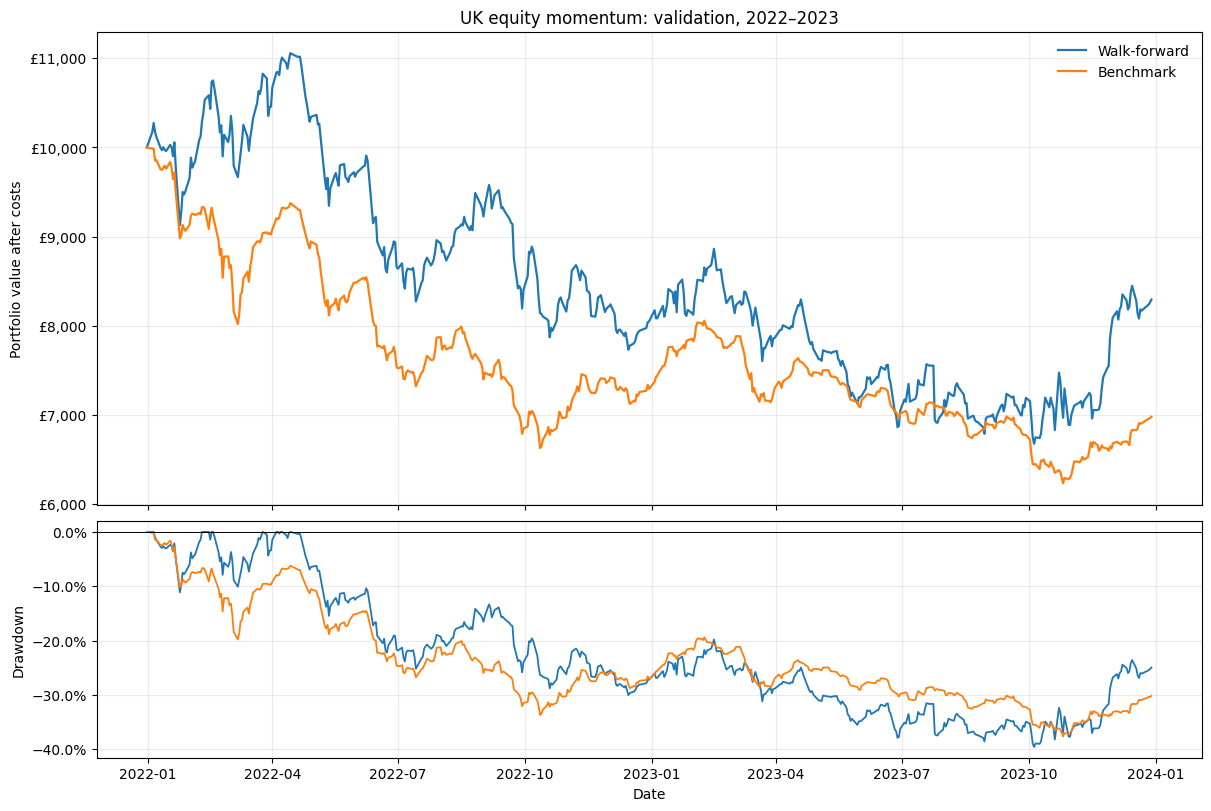

In [ ]:
validation = momentum_research.run_walk_forward_period(
    sweep, prepared["market"], schedule, PROTOCOL, PERIODS["validation"])
display(validation["choices"][CHOICES].round(3))
display(validation["summary"][METRICS].round(2))
display(validation["annual"].round(2))
fig, axes = momentum_plotting.plot_equity_and_drawdown(
    validation["equity"], initial_capital_gbp=CAPITAL,
    start_date=schedule.index[schedule.index.get_loc(validation["equity"].index[0]) - 1],
    title="UK equity momentum: validation, 2022 - 2023")

Momentum loses less than the benchmark in 2022 and outperforms again in 2023. It finishes at £8,295.28, compared with £6,980.66. Both portfolios lose money over the full period, and momentum has greater volatility and a slightly worse maximum drawdown.

In [10]:
validation_inference = momentum_research.test_net_excess(
    validation["net_returns"][["Walk-forward"]], validation["net_returns"]["Benchmark"],
    PROTOCOL["inference"])
display(validation_inference[TEST_COLUMNS].rename(
    columns={"reject_holm": "reject_null"}).round(4))

,,mean_daily_net_excess_bps,lower_ci_bps,upper_ci_bps,p_one_sided,reject_null
block_length,configuration_id,,,,,
21,Walk-forward,4.2128,-5.2645,12.9577,0.1723,False
63,Walk-forward,4.2128,-5.9791,13.9391,0.2128,False
126,Walk-forward,4.2128,-6.7723,13.7972,0.2170,False


Mean daily net excess is +4.213bp, with a primary 95% interval of [-5.979, +13.939]bp and one-sided p-value of 0.2128. All intervals contain zero. Neither evaluation rejects the null. There is only one adaptive strategy in each evaluation, so its Holm-adjusted p-value is the same as its unadjusted value.

## Holdout: 2024–2025

Apply the same annual selection rule identically to above. Completed holdout-year observations can enter the next year's training under the already fixed rule. Start both portfolios from £10,000 cash, then carry holdings across year boundaries. 

,train_start,train_end,test_start,configuration_id,formation_sessions,skip_sessions,top_frac,training_sharpe
fold,,,,,,,,
5,2021-01-04,2023-12-29,2024-01-02,15,252,21,0.1,-0.378
6,2022-01-04,2024-12-31,2025-01-02,9,189,21,0.1,0.130


,final_equity_gbp,total_return_pct,net_cagr_pct,volatility_pct,sharpe_zero_rf,max_drawdown_pct,annual_two_way_turnover,total_cost_gbp
Walk-forward,9335.05,-6.65,-3.36,25.46,-0.01,-26.05,9.00,169.52
Benchmark,9957.13,-0.43,-0.21,11.73,0.04,-26.43,3.17,62.92


,Walk-forward,Benchmark,gap_pp
year,,,
2024,-12.15,-5.91,-6.24
2025,6.26,5.83,0.43


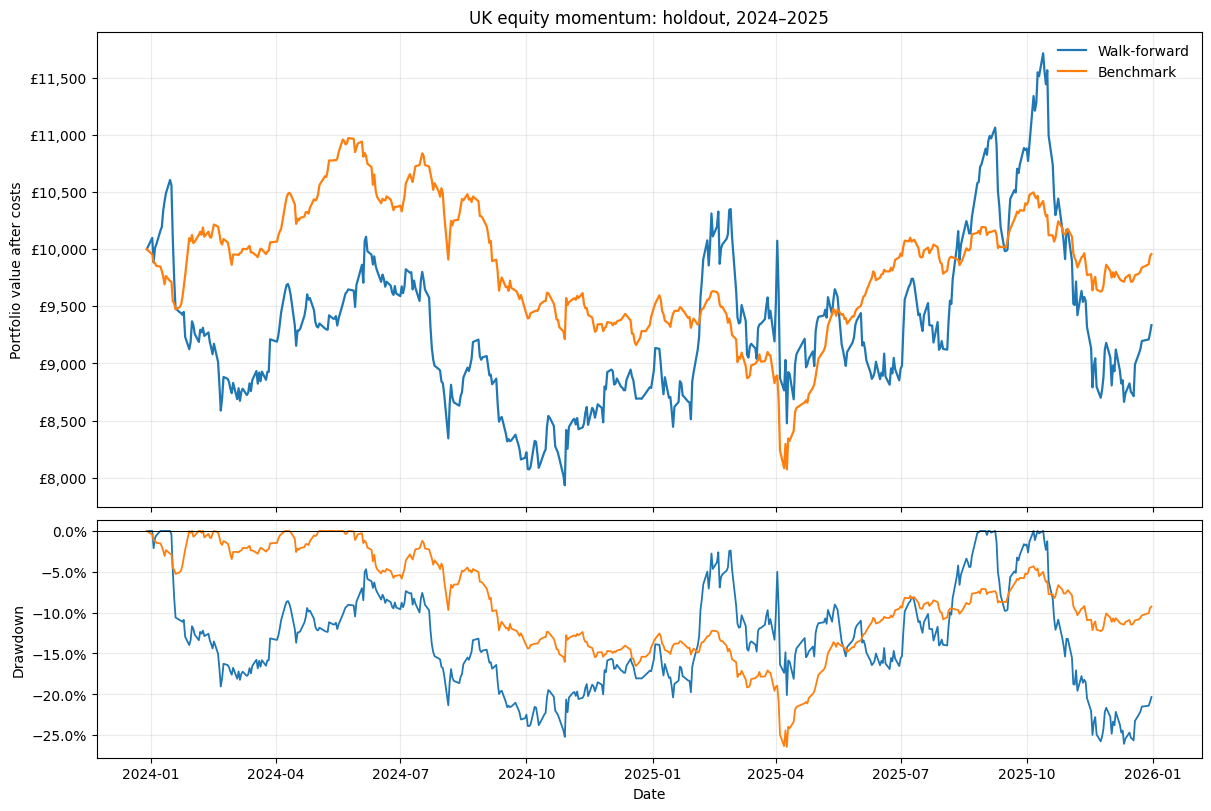

In [ ]:
holdout = momentum_research.run_walk_forward_period(
    sweep, prepared["market"], schedule, PROTOCOL, PERIODS["holdout"])
display(holdout["choices"][CHOICES].round(3))
display(holdout["summary"][METRICS].round(2))
display(holdout["annual"].round(2))
holdout_fig, axes = momentum_plotting.plot_equity_and_drawdown(
    holdout["equity"], initial_capital_gbp=CAPITAL,
    start_date=schedule.index[schedule.index.get_loc(holdout["equity"].index[0]) - 1],
    title="UK equity momentum: holdout, 2024 - 2025")

Configuration 15 is chosen for 2024, then configuration 9 for 2025. Both select the top 10%, skipping 21 sessions, but formation changes from 252 to 189 sessions.

Momentum outperforms in both validation years, but both portfolios lose money over the period. It then underperforms by 6.24% in 2024 and outperforms by only 0.43% in 2025. The upward spikes do not become a sustained cumulative advantage. Volatility is 25.46%, versus 11.73% for the benchmark, with similar maximum drawdowns.

In [12]:
holdout_inference = momentum_research.test_net_excess(
    holdout["net_returns"][["Walk-forward"]], holdout["net_returns"]["Benchmark"],
    PROTOCOL["inference"])
display(holdout_inference[TEST_COLUMNS].rename(
    columns={"reject_holm": "reject_null"}).round(4))

,,mean_daily_net_excess_bps,lower_ci_bps,upper_ci_bps,p_one_sided,reject_null
block_length,configuration_id,,,,,
21,Walk-forward,-0.2576,-13.0344,12.3889,0.5206,False
63,Walk-forward,-0.2576,-10.6613,9.8920,0.5141,False
126,Walk-forward,-0.2576,-9.2834,8.5030,0.5182,False


Mean daily net excess is -0.2576bp. All intervals contain zero, and all p-values are ~0.52, leading to us finding no statistcal edge compared to the benchmark.

## Conclusion

- The strongest fixed development configurations did not establish statistically significant excess returns. The baseline finished close to the benchmark, but also came with greater risk and trading costs.
- Annual selection underperformed in the development diagnostic, lost less than the benchmark in validation, then underperformed in the holdout. The relative results vary substantially across years.
- Neither validation nor holdout establishes positive mean daily net excess. This does not prove that momentum has no advantage, but there is insufficient evidence to support choosing this version for standalone implementation.
- The 10bp per-side cost is a model, not a measured spread or a maximum fee guarantee. Moreover, the selection list also includes survivorship bias.